In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la

In [3]:
def initial_condition(x):
    u = np.zeros_like(x)
    for i in range(len(x)):
        if x[i] <= 0.5:
            u[i] = 2 * x[i]
        else:
            u[i] = 2 - 2 * x[i]
    return u

In [4]:
dx = 0.05
dt = 0.005
t_max = 0.06

x = np.arange(0, 1.0 + dx / 2, dx)
t = np.arange(0, t_max + dt / 2, dt)
Nx = len(x)
Nt = len(t)

In [5]:
u_cn = np.zeros((Nt, Nx))
u_cn[0, :] = initial_condition(x)

In [6]:
sigma = dt / (2 * dx**2)

A = np.zeros((Nx - 2, Nx - 2))
for i in range(Nx - 2):
    A[i, i] = 1 + 2 * sigma
    if i > 0:
        A[i, i - 1] = -sigma
    if i < Nx - 3:
        A[i, i + 1] = -sigma

In [7]:
for k in range(0, Nt - 1):
    b = np.zeros(Nx - 2)
    for i in range(1, Nx - 1):
        b[i - 1] = (
            sigma * u_cn[k, i - 1]
            + (1 - 2 * sigma) * u_cn[k, i]
            + sigma * u_cn[k, i + 1]
        )

    u_interior = la.solve(A, b)
    u_cn[k + 1, 1:-1] = u_interior

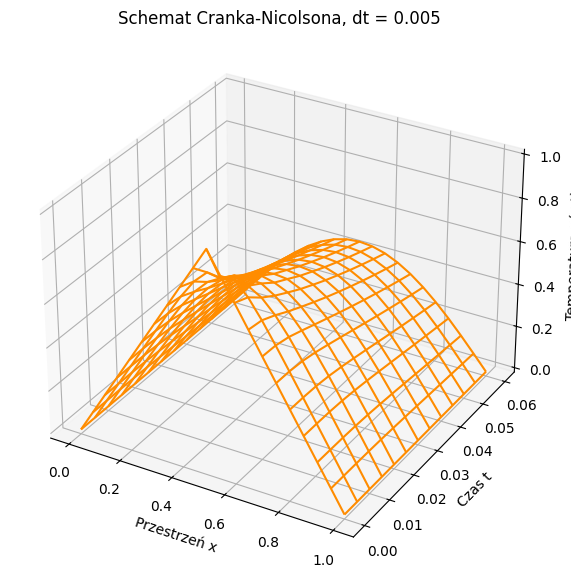

In [8]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
X_cn, T_cn = np.meshgrid(x, t)
ax.plot_wireframe(X_cn, T_cn, u_cn, color="darkorange")

ax.set_xlabel("Przestrzeń x")
ax.set_ylabel("Czas t")
ax.set_zlabel("Temperatura u(x,t)")
ax.set_title("Schemat Cranka-Nicolsona, dt = 0.005")
plt.show()